In [1]:
print("Başladık")


Başladık


In [2]:
import pandas as pd
import numpy as np

In [3]:
np.random.seed(42)
n=500

In [4]:
data={
    "CustomerID": np.random.randint(1000, 1100, n),
    "OrderID": np.arange(1, n+1),
    "OrderDate": pd.date_range(start="2023-01-01", periods=n, freq="D"),
    "Sales": np.random.randint(50, 500, n),
    "Profit": np.random.randint(-20, 150, n),
    "Category": np.random.choice(["Teknoloji", "Mobilya", "Ofis Malzemeleri"],),
    "City": np.random.choice(["İstanbul", "Ankara", "İzmir"], n)
}


In [5]:
df = pd.DataFrame(data)

df.head()

,CustomerID,OrderID,OrderDate,Sales,Profit,Category,City
0,1051,1,2023-01-01,125,5,Mobilya,Ankara
1,1092,2,2023-01-02,203,26,Mobilya,İstanbul
2,1014,3,2023-01-03,193,100,Mobilya,İstanbul
3,1071,4,2023-01-04,484,35,Mobilya,Ankara
4,1060,5,2023-01-05,135,73,Mobilya,İzmir


In [6]:
df.groupby("Category")[["Sales", "Profit"]].sum().sort_values("Profit", ascending=False)

,Sales,Profit
Category,,
Mobilya,138268,31331


In [7]:
df.to_csv("data/sales.csv" , index=False)

In [8]:
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
profit_margin = total_profit / total_sales

total_sales, total_profit, profit_margin

(np.int64(138268), np.int64(31331), np.float64(0.2265961755431481))

In [9]:
df.groupby("Category")[["Sales", "Profit"]].sum().sort_values("Profit", ascending=False)

,Sales,Profit
Category,,
Mobilya,138268,31331


In [10]:
df.groupby("City")[["Sales", "Profit"]].sum().sort_values("Profit", ascending=False)

,Sales,Profit
City,,
İstanbul,49328,11383
Ankara,46290,10121
İzmir,42650,9827


In [11]:
# İstanbul en yüksek satış ve kârlılığa sahip ana pazardır.
# Ankara orta seviyede performans göstermektedir.
# İzmir ise hem satış hem kârlılık açısından daha düşük performans sergilemektedir.
# Bu nedenle İzmir'de pazarlama veya satış stratejileri gözden geçirilebilir.

In [12]:
df["OrderDate"] = pd.to_datetime(df["OrderDate"])

monthly_sales = df.groupby(df["OrderDate"].dt.to_period("M"))["Sales"].sum()

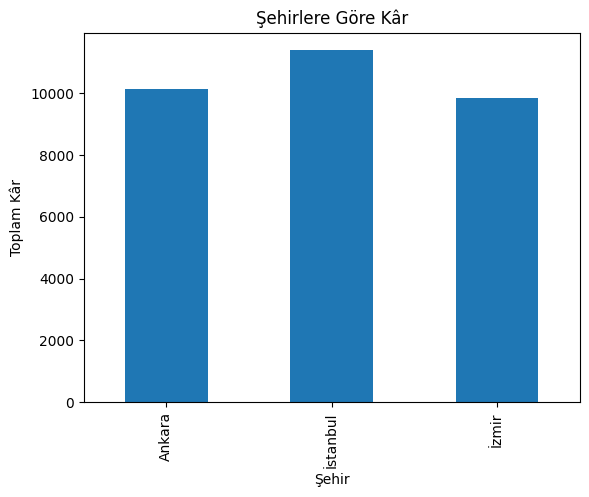

In [13]:
import matplotlib.pyplot as plt

df.groupby("City")["Profit"].sum().plot(kind="bar")
plt.title("Şehirlere Göre Kâr")
plt.xlabel("Şehir")
plt.ylabel("Toplam Kâr")
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

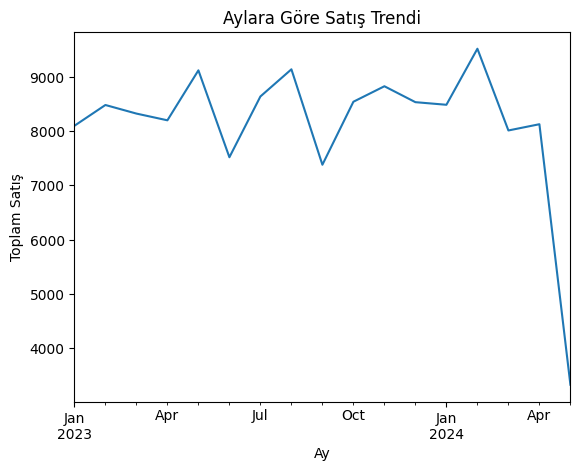

In [14]:
import matplotlib.pyplot as plt

monthly_sales.plot()
plt.title("Aylara Göre Satış Trendi")
plt.xlabel("Ay")
plt.ylabel("Toplam Satış")
plt.show

In [15]:
rfm = df.groupby("CustomerID").agg({
    "OrderDate": lambda x: (df["OrderDate"].max() - x.max()).days,
    "OrderID": "count",
    "Sales": "sum"
})

rfm.columns = ["Recency", "Frequency", "Monetary"]

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
1000,8,9,2580
1001,97,10,3559
1002,198,7,2214
1003,138,5,855
1004,41,3,900


In [16]:
# Her müşteri için;
# Recency-> en son ne zaman alışveriş yaptı
# Frequency-> kaç kez alışveriş yaptı
# Monetary-> ne kadar harcadı
# Yani burda müşteri davranışlarını çıkarıyoruz

In [17]:
from sklearn.preprocessing import StandardScaler


In [18]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)